# Requirements Classification Experiment

## Comparing Prompt Techniques with Energy Measurement


 ### 1. Setup and Configuration

In [84]:
pip install pandas numpy requests scikit-learn matplotlib seaborn tqdm codecarbon

Note: you may need to restart the kernel to use updated packages.


In [85]:
# Import required libraries
import os
import time
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from codecarbon import EmissionsTracker
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import re
from prompts import BASE_PROMPTS, generate_prompt_variations, count_tokens

# Configuration
DATA_FOLDER = "PROMISE"
MODEL_NAME = "llama3.2"
N_REPETITIONS = 1
REST_TIME = 1
SEED_RANGE = range(N_REPETITIONS)
WARMUP_ITERATIONS = 2
TEST_SIZE = 0.005

# Ensure directories exist
os.makedirs("emissions", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Initialize timers
total_start_time = time.time()
experiment_start_time = None

### 2. Data Loading and Preparation

In [86]:
DATA_FOLDER = "PROMISE"

DATA_FOLDER = "PROMISE"

def load_and_merge_promise_data(folder_path):
    """Load and merge both traind.txt and testd.txt from PROMISE dataset (2 columns: label, text)"""
    files = ['traind.txt', 'testd.txt']
    dfs = []
    for filename in files:
        try:
            filepath = os.path.join(folder_path, filename)
            df = pd.read_csv(filepath, header=None, names=['label', 'text'], sep=',', dtype=str)
            dfs.append(df)
            print(f"Loaded {filename} with {len(df)} samples")
        except Exception as e:
            print(f"Error loading {filename}: {str(e)}")
            dfs.append(pd.DataFrame(columns=['label', 'text']))
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df

def clean_data(df):
    """Clean and standardize labels"""
    df['label'] = df['label'].str.strip().str.upper().replace(
        {'FR': 'F', 'FUNCTIONAL': 'F', 'FUNCTIONALITY': 'F',
         'NFR': 'NF', 'NON-FUNCTIONAL': 'NF', 'NONFUNCTIONAL': 'NF'}
    )
    df = df[df['label'].isin(['F', 'NF'])]  # Keep only valid labels
    df['text'] = df['text'].str.strip()
    return df.dropna()

# Load, merge and clean all data
full_df = clean_data(load_and_merge_promise_data(DATA_FOLDER))

print("\nDataset Statistics:")
print(f"Total samples: {len(full_df)}")
print("Label distribution:")
print(full_df['label'].value_counts())

Loaded traind.txt with 572 samples
Loaded testd.txt with 83 samples

Dataset Statistics:
Total samples: 655
Label distribution:
label
NF    389
F     266
Name: count, dtype: int64


In [87]:
full_df = clean_data(load_and_merge_promise_data(DATA_FOLDER))
print(full_df.head())
print(full_df['label'].value_counts())

Loaded traind.txt with 572 samples
Loaded testd.txt with 83 samples
  label                                               text
0    NF  The system shall refresh the display every 60 ...
1    NF  The application shall match the color of the s...
2    NF  If projected  the data must be readable.  On a...
3    NF  The product shall be available during normal b...
4    NF  If projected  the data must be understandable....
label
NF    389
F     266
Name: count, dtype: int64


### 3. Helper Functions

In [88]:
def load_and_merge_promise_data(folder_path):
    """Load and merge dataset files with progress tracking"""
    files = ['traind.txt', 'testd.txt']
    dfs = []
    for filename in tqdm(files, desc="Loading data files"):
        try:
            filepath = os.path.join(folder_path, filename)
            df = pd.read_csv(filepath, header=None, names=['label', 'text'], sep=',', dtype=str)
            dfs.append(df)
        except Exception as e:
            print(f"Error loading {filename}: {str(e)}")
            dfs.append(pd.DataFrame(columns=['label', 'text']))
    return pd.concat(dfs, ignore_index=True)

def clean_data(df):
    """Clean and standardize labels"""
    with tqdm(total=4, desc="Cleaning data") as pbar:
        df['label'] = df['label'].str.strip().str.upper().replace(
            {'FR': 'F', 'FUNCTIONAL': 'F', 'FUNCTIONALITY': 'F',
             'NFR': 'NF', 'NON-FUNCTIONAL': 'NF', 'NONFUNCTIONAL': 'NF'})
        pbar.update(1)
        df = df[df['label'].isin(['F', 'NF'])]
        pbar.update(1)
        df['text'] = df['text'].str.strip()
        pbar.update(1)
        df = df.dropna()
        pbar.update(1)
    return df

def fibonacci_warmup(n):
    """Run Fibonacci sequence for warmup"""
    a, b = 0, 1
    for _ in tqdm(range(n), desc="Warming up"):
        a, b = b, a + b
    return a

def query_ollama(prompt, model=MODEL_NAME, max_retries=3):
    """Query Ollama API with retries"""
    url = "http://localhost:11434/api/generate"
    payload = {"model": model, "prompt": prompt, "stream": False}
    
    for attempt in range(max_retries):
        try:
            response = requests.post(url, json=payload, timeout=120)
            if response.status_code == 200:
                return response.json()["response"].strip()
            print(f"Retry {attempt + 1}: API error {response.status_code}")
        except Exception as e:
            print(f"Retry {attempt + 1}: {str(e)}")
        time.sleep(2)
    return "ERROR"

### 4. Core Experiment Functions

In [89]:
def create_stratified_split(df, seed, test_size=TEST_SIZE):
    """Create stratified split with progress tracking"""
    with tqdm(total=1, desc=f"Creating split (seed {seed})") as pbar:
        train_df, test_df = train_test_split(
            df, test_size=test_size, random_state=seed, stratify=df['label'])
        pbar.update(1)
    return train_df, test_df

def classify_requirement(text, prompt_template, prompt_type, complexity_level, length_type):
    """Classify requirement with full tracking"""
    prompt = prompt_template.format(text=text)
    token_count = count_tokens(prompt)
    
    tracker = EmissionsTracker(
        project_name=f"req_classification_{prompt_type}",
        measure_power_secs=1,
        output_dir="emissions",
        log_level="error"
    )
    
    tracker.start()
    start_time = time.time()
    
    response = query_ollama(prompt).upper().strip()
    
    inference_time = time.time() - start_time
    emissions = tracker.stop()
    
    # Parse response
    pred = "UNKNOWN"
    if "FUNCTIONAL" in response or "F" in response:
        pred = "F"
    elif "NON-FUNCTIONAL" in response or "NF" in response:
        pred = "NF"
    
    return {
        'prediction': pred,
        'inference_time': inference_time,
        'energy': emissions * 1000,
        'carbon_emission': emissions,
        'token_count': token_count,
        'prompt_used': prompt,
        'prompt_type': prompt_type,
        'complexity_level': complexity_level,
        'length_type': length_type
    }

### 4. Main Experiment Execution

In [90]:
def run_experiment():
    """Run full experiment with progress tracking"""
    global experiment_start_time
    experiment_start_time = time.time()
    
    # Load and clean data
    print("\n" + "="*50)
    print("Starting Experiment")
    print(f"Configuration: {N_REPETITIONS} reps | {TEST_SIZE} test size | {MODEL_NAME}")
    print("="*50 + "\n")
    
    data_load_start = time.time()
    df = load_and_merge_promise_data(DATA_FOLDER)
    df = clean_data(df)
    print(f"\nData loaded in {time.time() - data_load_start:.2f} seconds")
    
    results = []
    total_classifications = N_REPETITIONS * len(BASE_PROMPTS) * 9 * int(len(df)*TEST_SIZE)
    
    # Main experiment loop
    with tqdm(total=total_classifications, desc="Overall Progress") as main_pbar:
        for seed in tqdm(SEED_RANGE, desc="Repetitions"):
            rep_start_time = time.time()
            train_df, test_df = create_stratified_split(df, seed)
            
            for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Seed {seed} samples", leave=False):
                text = row['text']
                true_label = row['label']
                
                for prompt_name, prompt_template in tqdm(BASE_PROMPTS.items(), desc="Prompt types", leave=False):
                    if prompt_name == 'alessio_system' or "{text}" not in prompt_template:
                        continue
                        
                    variations = generate_prompt_variations(prompt_template, text)
                    
                    for variation in variations:
                        result = classify_requirement(
                            text=text,
                            prompt_template=prompt_template,
                            prompt_type=prompt_name,
                            complexity_level=variation['complexity'],
                            length_type=variation['type']
                        )
                        
                        # Calculate metrics
                        if result['prediction'] in ['F', 'NF']:
                            accuracy = 1 if result['prediction'] == true_label else 0
                            precision = accuracy
                            recall = accuracy
                            f1 = accuracy
                        else:
                            accuracy = precision = recall = f1 = 0
                        
                        results.append({
                            'dataset_name': 'PROMISE',
                            'iteration_number': seed,
                            'LLM_name': MODEL_NAME,
                            'Prompt_type': prompt_name,
                            'Prompt_used': result['prompt_used'],
                            'Token_Length': result['token_count'],
                            'Length_type': result['length_type'],
                            'Level_complexity': result['complexity_level'],
                            'accuracy': accuracy,
                            'f1_score': f1,
                            'precision': precision,
                            'recall': recall,
                            'inference_time': result['inference_time'],
                            'energy': result['energy'],
                            'carbon_emission': result['carbon_emission'],
                            'true_label': true_label,
                            'pred_label': result['prediction']
                        })
                        
                        main_pbar.update(1)
            
            # Save intermediate results
            pd.DataFrame(results).to_csv("results/experiment_results3.csv", index=False)
            print(f"\nRepetition {seed} completed in {time.time() - rep_start_time:.2f}s")
    
    return pd.DataFrame(results)

# Execution with timing
print("Initializing...")
fibonacci_warmup(WARMUP_ITERATIONS)
time.sleep(5)

results_df = run_experiment()
results_df.to_csv("results/final_experiment_results3.csv", index=False)

total_time = time.time() - total_start_time
experiment_time = time.time() - experiment_start_time

print("\n" + "="*50)
print("Experiment Complete!")
print(f"Total runtime: {total_time/3600:.2f} hours")
print(f"Active experiment time: {experiment_time/3600:.2f} hours")
print(f"Processed {len(results_df)} classifications")
print(f"Average time per classification: {experiment_time/len(results_df):.2f}s")
print("="*50)

Initializing...


Warming up: 100%|██████████| 2/2 [00:00<00:00, 2649.59it/s]



Starting Experiment
Configuration: 1 reps | 0.005 test size | llama3.2



Cleaning data: 100%|██████████| 4/4 [00:00<00:00, 387.29it/s]



Data loaded in 0.09 seconds


Creating split (seed 0): 100%|██████████| 1/1 [00:00<00:00, 79.97it/s]



/usr/local/lib/python3.10/site-packages/codecarbon/output_methods/file.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_df])
Overall Progress:   1%|          | 1/162 [00:16<44:36, 16.63s/it]/usr/local/lib/python3.10/site-packages/codecarbon/output_methods/file.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_df])
Overall Progress:   1%|          | 2/162 [00:29<38:51, 


Repetition 0 completed in 3476.00s

Experiment Complete!
Total runtime: 0.97 hours
Active experiment time: 0.97 hours
Processed 180 classifications
Average time per classification: 19.31s


### 5. Visualization


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']

Performance Statistics:
- Average inference time: 8.64s
- Total energy used: 0.01 kWh
- Total carbon emissions: 8.48 gCO2


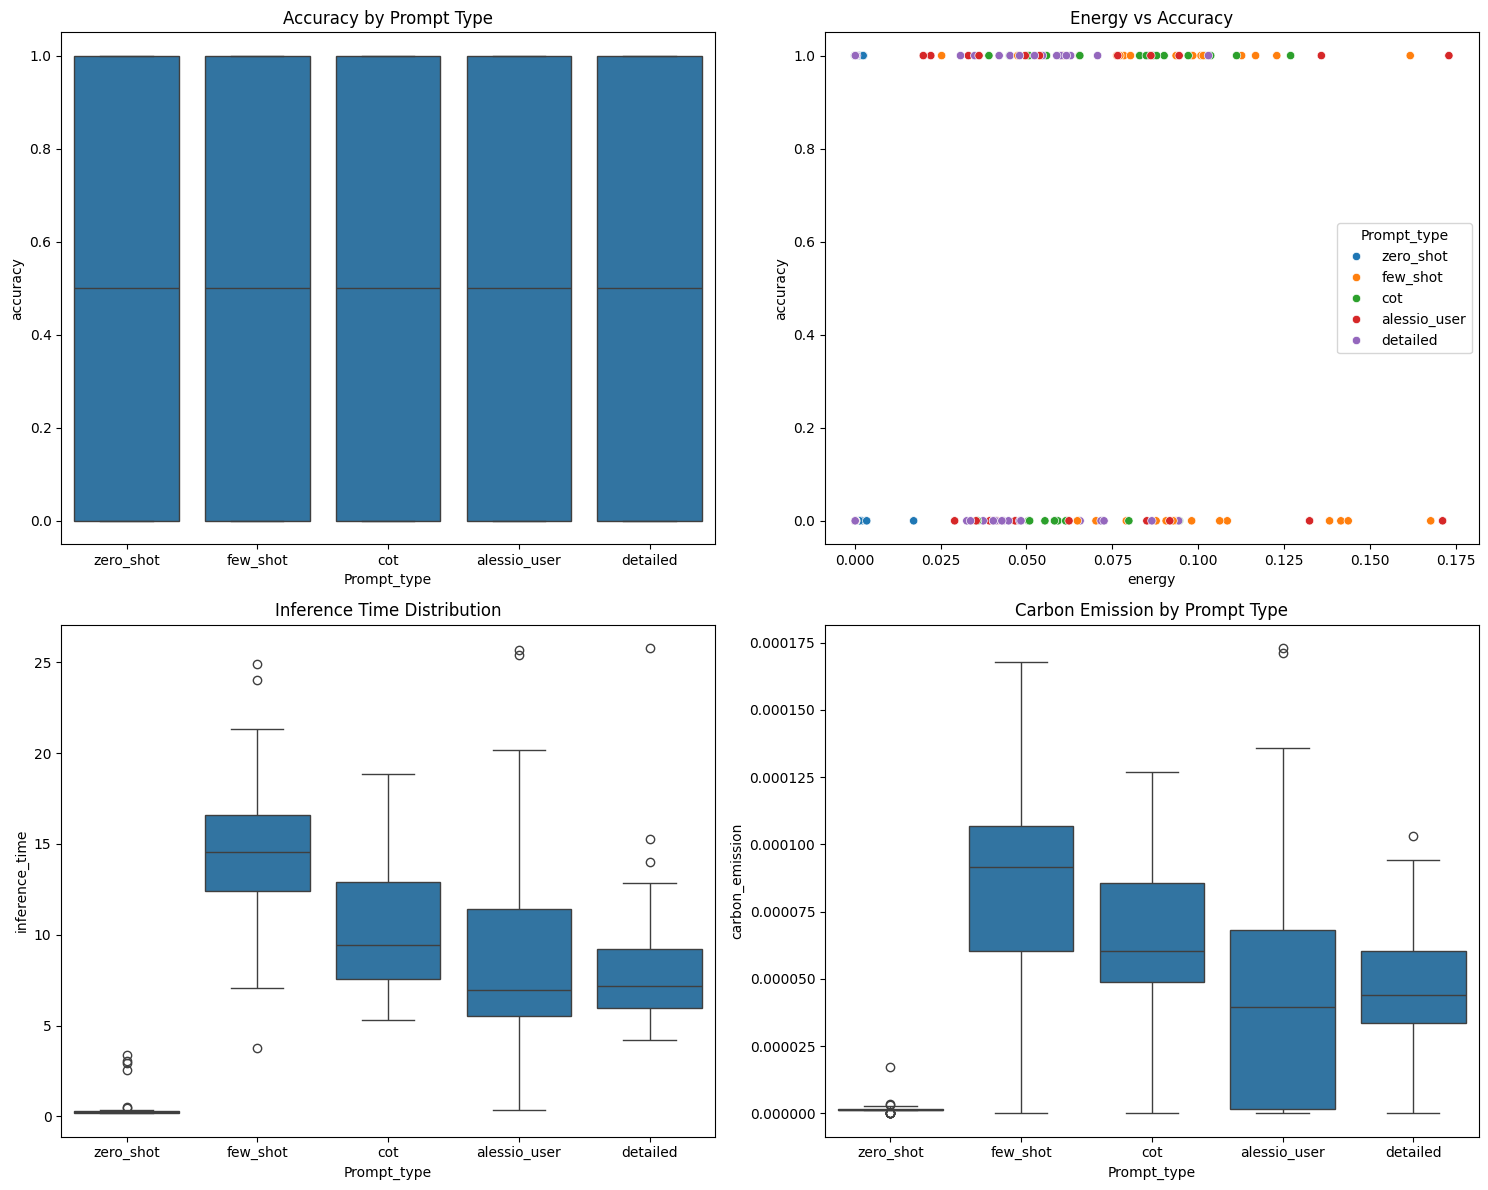

In [92]:
def generate_plots(results_df):
    """Generate plots with runtime info"""
    print(plt.style.available)
    
    # Runtime stats
    print("\nPerformance Statistics:")
    print(f"- Average inference time: {results_df['inference_time'].mean():.2f}s")
    print(f"- Total energy used: {results_df['energy'].sum()/1000:.2f} kWh")
    print(f"- Total carbon emissions: {results_df['carbon_emission'].sum()*1000:.2f} gCO2")
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Accuracy by Prompt Type
    sns.boxplot(data=results_df, x='Prompt_type', y='accuracy', ax=axes[0,0])
    axes[0,0].set_title('Accuracy by Prompt Type')
    
    # Energy vs Accuracy
    sns.scatterplot(data=results_df, x='energy', y='accuracy', hue='Prompt_type', ax=axes[0,1])
    axes[0,1].set_title('Energy vs Accuracy')
    
    # Inference Time Distribution
    sns.boxplot(data=results_df, x='Prompt_type', y='inference_time', ax=axes[1,0])
    axes[1,0].set_title('Inference Time Distribution')
    
    # Carbon Emission
    sns.boxplot(data=results_df, x='Prompt_type', y='carbon_emission', ax=axes[1,1])
    axes[1,1].set_title('Carbon Emission by Prompt Type')
    
    plt.tight_layout()
    plt.savefig('plots/experiment_results3.png', dpi=300)
    plt.show()

generate_plots(results_df)